In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder

class FeedForwardNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(FeedForwardNetwork, self).__init__()
        self.ffn = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),  # Add dropout here
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.ffn(x)

class SimpleVATTEmotionPredictor(nn.Module):
    def __init__(self, audio_dim, text_dim, common_space_dim, hidden_dim, num_classes):
        super(SimpleVATTEmotionPredictor, self).__init__()

        self.audio_ffn = FeedForwardNetwork(audio_dim, hidden_dim)
        self.text_ffn = FeedForwardNetwork(text_dim, hidden_dim)

         # Projection heads for common spaces
        self.audio_to_va = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )
        self.text_to_vt = nn.Sequential(
            nn.Linear(hidden_dim, common_space_dim),
            nn.BatchNorm1d(common_space_dim)
        )

         # The first linear layer should expect 2 * common_space_dim as input
        self.classifier = nn.Sequential(
            nn.Linear(common_space_dim * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.Linear(256, num_classes)
        )

    def forward(self, audio_features, text_features):
        audio_hidden = self.audio_ffn(audio_features)
        text_hidden = self.text_ffn(text_features)

         # Project features into common spaces
        z_a_va = self.audio_to_va(audio_hidden)
        z_t_vt = self.text_to_vt(text_hidden)

         # Concatenate the common space outputs
        combined_embedding = torch.cat([z_a_va, z_t_vt], dim=-1)

        emotion_logits = self.classifier(combined_embedding)

        return emotion_logits

In [ ]:
import pandas as pd

# Load files
df_audio = pd.read_csv("/content/drive/MyDrive/audio_features.csv")
df_text = pd.read_csv("/content/drive/MyDrive/urdu_embeddings_v2.csv")

print("Audio rows:", len(df_audio))
print("Text rows:", len(df_text))

Audio rows: 8579
Text rows: 8579


In [ ]:
print(df_audio["Link"].head())
print(df_text["Audio Link"].head())

0    Anger_26_1696.322259-1711.281021_Muqaddar Ka S...
1    Love_399_1567.090613-1574.09697_Mere Humsafar ...
2    Happy_12_602.843802-607.286653_Makafat_Naik Se...
3    Sad_19_370.119533-384.555565_Tere Bin Ep 05 - ...
4    Anger_2065.964265-2070.58085_Tere Bin Episode ...
Name: Link, dtype: object
0    Anger_18_875.908933-883.993211_OPPO presents S...
1    Anger_34_1083.39927-1090.118836_Muqaddar Ka Si...
2    Anger_16_0-4.944894_Anger_20_2370.497571-2389....
3    Happy_71_1562.565236-1566.70153_Shehnai Episod...
4    Happy_596_45.101902-57.910567_Happy_9_1266.510...
Name: Audio Link, dtype: object


In [ ]:
import os

df_audio["Link"] = df_audio["Link"].apply(lambda x: os.path.basename(str(x)))

In [ ]:
df_merged = pd.merge(
    df_audio,
    df_text,
    left_on="Link",
    right_on="Audio Link",
    how="inner"
)

print("Merged rows:", len(df_merged))

Merged rows: 8579


In [ ]:
df_merged = df_merged.drop(columns=["Audio Link"])


In [ ]:
audio_columns = [col for col in df_audio.columns if col not in ["Link", "Label"]]

audio_features = df_merged[audio_columns].values

In [ ]:
text_columns = df_text.columns.drop(["Audio Link","Label"])

text_features = df_merged[text_columns].values

In [ ]:
labels = df_merged["Label_x"].values
labels = df_merged["Label_y"].values

In [ ]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)  # Converts happy -> 0, sad -> 1, etc.
print("Classes:", le.classes_)

Classes: ['anger' 'happy' 'love' 'neutral' 'sad' 'unknown']


In [ ]:
from sklearn.preprocessing import StandardScaler

# --- 1. Scaling  ---
scaler_audio = StandardScaler()
scaler_text = StandardScaler()

# Scale Features
audio_features_scaled = scaler_audio.fit_transform(audio_features)
text_features_scaled = scaler_text.fit_transform(text_features)

# make tensors
audio_tensor = torch.tensor(audio_features_scaled, dtype=torch.float32)
text_tensor = torch.tensor(text_features_scaled, dtype=torch.float32)
label_tensor = torch.tensor(labels_encoded, dtype=torch.long)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(audio_tensor, text_tensor, label_tensor)

# 80-20 train-test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
audio_dim = audio_tensor.shape[1]
text_dim = text_tensor.shape[1]
num_classes = len(torch.unique(label_tensor))

model = SimpleVATTEmotionPredictor(
    audio_dim=audio_dim,
    text_dim=text_dim,
    common_space_dim=256,
    hidden_dim=512,
    num_classes=num_classes
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleVATTEmotionPredictor(
    audio_dim=audio_dim,
    text_dim=text_dim,
    common_space_dim=256,
    hidden_dim=512,
    num_classes=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

In [ ]:
epochs = 50
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for audio_batch, text_batch, label_batch in train_loader:

        audio_batch = audio_batch.to(device)
        text_batch = text_batch.to(device)
        label_batch = label_batch.to(device)

        optimizer.zero_grad()
        outputs = model(audio_batch, text_batch)
        loss = criterion(outputs, label_batch)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 5/50, Loss: 0.1269
Epoch 10/50, Loss: 0.1156
Epoch 15/50, Loss: 0.1112
Epoch 20/50, Loss: 0.1116
Epoch 25/50, Loss: 0.1101
Epoch 30/50, Loss: 0.0965
Epoch 35/50, Loss: 0.0921
Epoch 40/50, Loss: 0.0771
Epoch 45/50, Loss: 0.0863
Epoch 50/50, Loss: 0.0833


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for audio_batch, text_batch, label_batch in test_loader:

        audio_batch = audio_batch.to(device)
        text_batch = text_batch.to(device)
        label_batch = label_batch.to(device)

        outputs = model(audio_batch, text_batch)
        predicted = torch.argmax(outputs, dim=1)
        total += label_batch.size(0)
        correct += (predicted == label_batch).sum().item()

accuracy = correct / total * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 61.42%


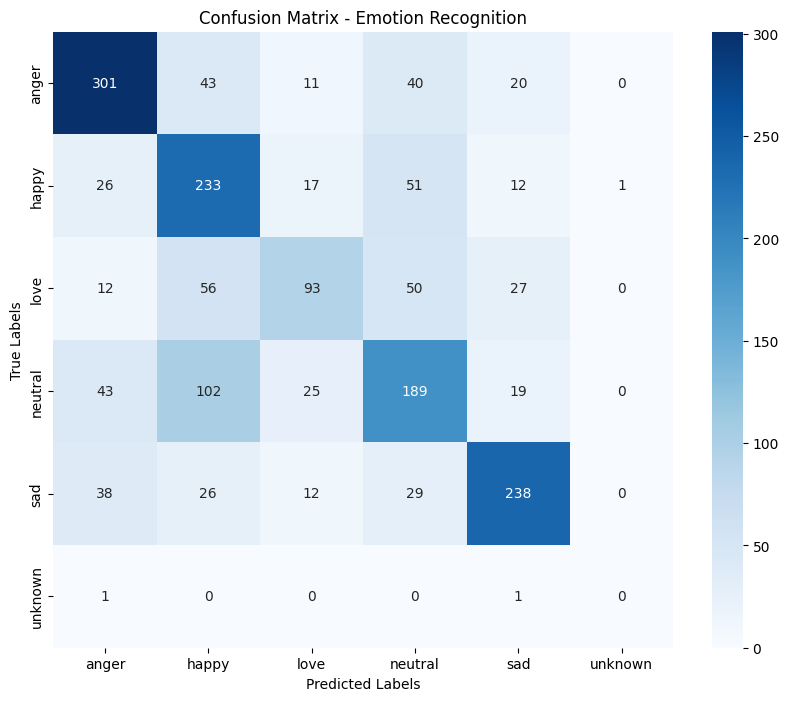


Classification Report:

              precision    recall  f1-score   support

       anger       0.71      0.73      0.72       415
       happy       0.51      0.69      0.58       340
        love       0.59      0.39      0.47       238
     neutral       0.53      0.50      0.51       378
         sad       0.75      0.69      0.72       343
     unknown       0.00      0.00      0.00         2

    accuracy                           0.61      1716
   macro avg       0.51      0.50      0.50      1716
weighted avg       0.62      0.61      0.61      1716



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for audio_batch, text_batch, label_batch in test_loader:
        #(GPU/CPU)
        audio_batch, text_batch = audio_batch.to(device), text_batch.to(device)

        outputs = model(audio_batch, text_batch)
        predicted = torch.argmax(outputs, dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(label_batch.numpy())

# 2.Calculate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
classes = le.classes_  # LabelEncoder

# 3. Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - Emotion Recognition')
plt.show()

# 4. Detailed Report (Precision, Recall, F1-Score)
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes))